# TabPFN

Nested leave-one-out CV (leakage-free) for model selection, then a one-shot evaluation on the held-out test set.

In [10]:
# CONFIG, LOAD RAW DATA, SPLIT, ASSEMBLE FEATURE MATRIX
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import json, random, warnings
from pathlib import Path
import joblib, numpy as np, pandas as pd, optuna, torch
from tabpfn import TabPFNRegressor
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, bootstrap
from sklearn.compose import ColumnTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PowerTransformer
from tqdm.auto import tqdm

RANDOM_STATE = 42
SPLIT_SEED = 1            
FULL_N_TRIALS = 50        
SMOKE = False
N_TRIALS = FULL_N_TRIALS if not SMOKE else 3
N_SPLITS_INNER = 5        
N_OUTER_JOBS = min(83, os.cpu_count() or 1)   
N_COMPONENTS = 5          
REDUCER = "pca"           
TARGET_TRANSFORM = "yeo-johnson"
TARGET_COL = "max_power_density_w_m2"
TABPFN_N_JOBS = 1         
TABPFN_DEVICE = "cpu"     
PERM_REPEATS = 5         
torch.set_num_threads(TABPFN_N_JOBS)
MODEL_NAME = "TabPFN"
BASE_DIR = Path("/home/duongtt2/bes/Gusim")
os.chdir(BASE_DIR)       
assert BASE_DIR.is_dir(), f"BASE_DIR does not exist: {BASE_DIR}"

RUN_NAME = f"{REDUCER}_{N_COMPONENTS}d"
RESULT_DIR = BASE_DIR / "model_results" / "tabpfn" / RUN_NAME / f"{TARGET_TRANSFORM}_loocv_{FULL_N_TRIALS}trials"
if SMOKE:   # a 3-trial smoke run must never overwrite real 50-trial results
    RESULT_DIR = RESULT_DIR.with_name(RESULT_DIR.name + "_SMOKE")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

NUMERIC_FEATURES = ["initial_conc_g_cod_l","anode_surface_area_m2","anolyte_volume_ml",
    "cathode_surface_area_m2","catholyte_volume_ml","pH","temperature_c",
    "anode_S_V_ratio_m2_m3","cathode_S_V_ratio_m2_m3"]
TEXT_VALUE_COLUMNS = ["substrate_type","anode_material","cathode_material"]
DESC = ["substrate_description","anode_description","cathode_description"]

df = pd.read_csv(BASE_DIR / "MFC_dataset_checked_description_cleaned.csv", encoding="utf-8-sig")
npz = np.load(BASE_DIR / "embedding_cache" / "pubmedbert_description_embeddings.npz")
assert all(npz[c].shape[0] == len(df) for c in DESC), "embedding cache not row-aligned with CSV"

X_all = np.hstack([df[NUMERIC_FEATURES].to_numpy(float), npz[DESC[0]], npz[DESC[1]], npz[DESC[2]]])
y_all = df[TARGET_COL].to_numpy(float)

# same locked 83/15 split as the nested-CV baseline (identical test set)
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.15, random_state=SPLIT_SEED, shuffle=True)
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]
train_src, test_src = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

n = len(NUMERIC_FEATURES)
NUM_IDX = list(range(0, n))
SUB_IDX = list(range(n, n+768)); ANO_IDX = list(range(n+768, n+2*768)); CAT_IDX = list(range(n+2*768, n+3*768))
FEATURE_NAMES = NUMERIC_FEATURES \
    + [f"substrate_desc_emb_{i+1}" for i in range(N_COMPONENTS)] \
    + [f"anode_desc_emb_{i+1}" for i in range(N_COMPONENTS)] \
    + [f"cathode_desc_emb_{i+1}" for i in range(N_COMPONENTS)]

def combo(d): return d[TEXT_VALUE_COLUMNS].astype(str).apply(lambda s: s.str.strip().str.lower()).agg("||".join, axis=1)
train_combos = set(combo(train_src))
ood_mask = (~combo(test_src).isin(train_combos)).to_numpy()

print(f"train={X_train.shape}  test={X_test.shape}  raw_features={X_all.shape[1]} -> after {REDUCER.upper()}={len(FEATURE_NAMES)}")
print(f"numeric NaNs in train: {int(np.isnan(X_train[:, NUM_IDX]).sum())}  (imputed inside each fold)")
print(f"OOD test rows (unseen material combo): {int(ood_mask.sum())} of {len(y_test)}")
print(f"Outer LOO folds: {len(y_train)} | parallel workers: {N_OUTER_JOBS} | inner tuning: {N_SPLITS_INNER}-fold x {N_TRIALS} trials")
print(f"Result dir: {RESULT_DIR}")

train=(83, 2313)  test=(15, 2313)  raw_features=2313 -> after PCA=24
numeric NaNs in train: 90  (imputed inside each fold)
OOD test rows (unseen material combo): 10 of 15
Outer LOO folds: 83 | parallel workers: 83 | inner tuning: 5-fold x 50 trials
Result dir: /home/duongtt2/bes/Gusim/model_results/tabpfn/pca_5d/yeo-johnson_loocv_50trials


In [11]:
# HELPERS: preprocessing pipeline, target transform, metrics, bootstrap CI, fit/predict, inner-CV tuning
class PLSReducer(PLSRegression):
    # ColumnTransformer needs a 2D fit_transform; PLSRegression.fit_transform returns a (x,y) tuple.
    def fit_transform(self, X, y=None, **kw):
        return self.fit(X, y).transform(X)

def make_reducer():
    if REDUCER == "pca": return PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    if REDUCER == "pls": return PLSReducer(n_components=N_COMPONENTS)
    raise ValueError(f"unknown REDUCER={REDUCER!r}")

def build_preprocessor():
    # fit fresh inside every fold -> no leakage; reducer fit per description block
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUM_IDX),
        ("sub", make_reducer(), SUB_IDX),
        ("ano", make_reducer(), ANO_IDX),
        ("cat", make_reducer(), CAT_IDX),
    ])

def fit_target_transformer(y):
    return PowerTransformer(method=TARGET_TRANSFORM, standardize=True).fit(np.asarray(y, float).reshape(-1, 1))

def to_model_scale(y, tt):   return tt.transform(np.asarray(y, float).reshape(-1, 1)).ravel()
def to_orig_scale(y, tt):
    out = tt.inverse_transform(np.asarray(y, float).reshape(-1, 1)).ravel()
    out[np.isnan(out)] = 0.0    # guard rare inverse-transform NaN
    return out

def make_model(params):
    # auto_scale_n_estimators must be off, otherwise TabPFN overrides the tuned n_estimators
    return TabPFNRegressor(device=TABPFN_DEVICE, random_state=RANDOM_STATE, n_jobs=TABPFN_N_JOBS,
                           auto_scale_n_estimators=False, **params)

def suggest_params(trial):
    hi = 8 if not SMOKE else 2
    return {"n_estimators": trial.suggest_int("n_estimators", 1, hi),
            "softmax_temperature": trial.suggest_float("softmax_temperature", 0.5, 1.2),
            "average_before_softmax": trial.suggest_categorical("average_before_softmax", [False, True])}

def perm_importance(model, pre, tt, X, y, repeats=PERM_REPEATS):
    # TabPFN exposes no feature_importances_; use permutation importance (mean MAE increase,
    # original W/m2 scale) from the final model on the training rows -- the test set is never touched.
    Xt = pre.transform(X); y = np.asarray(y, float)
    base = mean_absolute_error(y, to_orig_scale(model.predict(Xt), tt))
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for j, name in enumerate(FEATURE_NAMES):
        deltas = []
        for _ in range(repeats):
            Xp = Xt.copy(); Xp[:, j] = rng.permutation(Xp[:, j])
            deltas.append(mean_absolute_error(y, to_orig_scale(model.predict(Xp), tt)) - base)
        rows.append({"feature": name, "importance": float(np.mean(deltas))})
    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)

def all_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    rho, pval = spearmanr(y_true, y_pred)   # rho + its two-sided significance p-value
    return {"mae": float(mean_absolute_error(y_true, y_pred)),
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "r2": float(r2_score(y_true, y_pred)),
            "spearman": float(rho) if np.isfinite(rho) else float("nan"),
            "pval": float(pval) if np.isfinite(pval) else float("nan")}

STAT_FNS = {"mae": lambda a, b: mean_absolute_error(a, b),
            "rmse": lambda a, b: float(np.sqrt(mean_squared_error(a, b))),
            "r2": lambda a, b: r2_score(a, b),
            "spearman": lambda a, b: spearmanr(a, b)[0]}

def bootstrap_ci(y_true, y_pred, key, n_resamples=5000):
    # paired BCa 95% CI on the pooled out-of-fold pairs; percentile fallback if BCa degenerates
    data = (np.asarray(y_true, float), np.asarray(y_pred, float))
    for method in ("BCa", "percentile"):
        try:
            res = bootstrap(data, STAT_FNS[key], paired=True, vectorized=False,
                            n_resamples=n_resamples, confidence_level=0.95,
                            method=method, random_state=RANDOM_STATE)
            return [float(res.confidence_interval.low), float(res.confidence_interval.high)]
        except Exception:
            continue
    return [float("nan"), float("nan")]

def fit_and_predict(X_fit, y_fit, X_eval, params):
    pre = build_preprocessor()
    Xf = pre.fit_transform(X_fit, np.asarray(y_fit, float)); Xe = pre.transform(X_eval)  # y used only by pls
    tt = fit_target_transformer(y_fit)
    model = make_model(params); model.fit(Xf, to_model_scale(y_fit, tt))
    pred = to_orig_scale(model.predict(Xe), tt)
    return model, pre, tt, pred

def tune_hyperparameters(X, y, sampler_seed, show_progress_bar=False):
    # One inner-CV Optuna search over (X, y). Preprocessing + target transform re-fit inside every inner fold.
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
    y = np.asarray(y, float)
    inner_cv = KFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
    def objective(trial):
        params = suggest_params(trial)
        maes = []
        for fit_idx, val_idx in inner_cv.split(X):
            _, _, _, pred = fit_and_predict(X[fit_idx], y[fit_idx], X[val_idx], params)
            maes.append(mean_absolute_error(y[val_idx], pred))
        return float(np.mean(maes))
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=sampler_seed))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=show_progress_bar)
    return study

In [12]:
# STEP 1: NESTED LOOCV -> main result. 83 outer folds (leave one sample out); inside each an
# independent inner 5-fold Optuna search tunes on the other 82 rows, then predicts the held-out row.
def loo_iteration(i):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore")
    keep = np.arange(len(y_train)) != i
    study = tune_hyperparameters(X_train[keep], y_train[keep], sampler_seed=RANDOM_STATE + i)
    _, _, _, pred = fit_and_predict(X_train[keep], y_train[keep], X_train[i:i+1], study.best_params)
    return i, float(pred[0]), float(study.best_value), study.best_params

results = []
gen = joblib.Parallel(n_jobs=N_OUTER_JOBS, return_as="generator")(
    joblib.delayed(loo_iteration)(i) for i in range(len(y_train)))
for r in tqdm(gen, total=len(y_train), desc="Step 1: nested LOOCV (outer folds)"):
    results.append(r)

oof = np.full(len(y_train), np.nan)
fold_rows = []
for i, pred, inner_mae, params in results:
    oof[i] = pred
    fold_rows.append({"outer_fold": i, "actual": float(y_train[i]), "predicted": pred,
                      "inner_best_cv_mae": inner_mae, **params})
assert not np.isnan(oof).any()

loocv_metrics = all_metrics(y_train, oof)          # r2 here is Q2 (computed on out-of-fold predictions)
loocv_ci = {k: bootstrap_ci(y_train, oof, k) for k in ["mae", "spearman", "rmse", "r2"]}   # no CI on the p-value (it is itself a significance measure)
loocv_summary = {"scheme": "nested_loocv",
                 "n_outer_folds": int(len(y_train)), "n_inner_folds": N_SPLITS_INNER, "n_trials": N_TRIALS,
                 "objective_metric": "mean_inner_kfold_cv_mae_unclipped_original_scale",
                 "metric_scale": "original_w_m2_after_inverse_transform",
                 "metrics": loocv_metrics, "ci95_bca": loocv_ci}

pd.DataFrame(fold_rows).to_csv(RESULT_DIR / "loocv_outer_folds.csv", index=False, encoding="utf-8-sig")
oof_df = train_src[TEXT_VALUE_COLUMNS].copy()
oof_df["actual"] = y_train; oof_df["predicted_oof"] = oof; oof_df["residual"] = y_train - oof
oof_df.to_csv(RESULT_DIR / "loocv_oof_predictions.csv", index=False, encoding="utf-8-sig")
with open(RESULT_DIR / "loocv_summary.json", "w", encoding="utf-8") as f:
    json.dump(loocv_summary, f, indent=2)

print("\n================ MAIN RESULT — Step 1 nested LOOCV (pooled over 83 out-of-fold predictions) ================")
print(f"  PRIMARY   {'MAE':<17}= {loocv_metrics['mae']:.4f}   95% CI [{loocv_ci['mae'][0]:.4f}, {loocv_ci['mae'][1]:.4f}]")
print(f"  PRIMARY   {'Spearman':<17}= {loocv_metrics['spearman']:.3f}    95% CI [{loocv_ci['spearman'][0]:.3f}, {loocv_ci['spearman'][1]:.3f}]")
print(f"  PRIMARY   {'Spearman p-value':<17}= {loocv_metrics['pval']:.2e}")
print(f"  secondary {'RMSE':<17}= {loocv_metrics['rmse']:.4f}   95% CI [{loocv_ci['rmse'][0]:.4f}, {loocv_ci['rmse'][1]:.4f}]")
print(f"  secondary {'Q2 (R2)':<17}= {loocv_metrics['r2']:.3f}    95% CI [{loocv_ci['r2'][0]:.3f}, {loocv_ci['r2'][1]:.3f}]")
print("==============================================================================================================")

Step 1: nested LOOCV (outer folds):   0%|          | 0/83 [00:00<?, ?it/s]


================ MAIN RESULT — Step 1 nested LOOCV (pooled over 83 out-of-fold predictions) ================
  PRIMARY   MAE              = 0.1648   95% CI [0.1238, 0.2345]
  PRIMARY   Spearman         = 0.427    95% CI [0.235, 0.591]
  PRIMARY   Spearman p-value = 5.78e-05
  secondary RMSE             = 0.2946   95% CI [0.2096, 0.4434]
  secondary Q2 (R2)          = 0.133    95% CI [-0.096, 0.449]


In [13]:
# STEP 1b + STEP 2: final hyperparameter search on all 83 rows, then retrain the deployed model
final_study = tune_hyperparameters(X_train, y_train, sampler_seed=RANDOM_STATE, show_progress_bar=True)
final_params = final_study.best_params
final_model, final_pre, final_tt, train_pred = fit_and_predict(X_train, y_train, X_train, final_params)
train_fit = all_metrics(y_train, train_pred)   # in-sample -> overfit check only, NOT a performance estimate

joblib.dump({"model": final_model, "preprocessor": final_pre, "target_transformer": final_tt,
             "target_transform": TARGET_TRANSFORM, "feature_names": FEATURE_NAMES},
            RESULT_DIR / "final_model.joblib")

print("Final hyperparameters (deployed model, tuned on all 83 rows):")
print(json.dumps(final_params, indent=2))
print(f"\nTrain fit (overfit check only): MAE={train_fit['mae']:.4f}  R2={train_fit['r2']:.3f}")

  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_602486/590867197.py:32: DeprecationWarning: TabPFNRegressor(n_jobs=...) is deprecated and has no effect. Use `n_preprocessing_jobs` instead.
  return TabPFNRegressor(device=TABPFN_DEVICE, random_state=RANDOM_STATE, n_jobs=TABPFN_N_JOBS,
/tmp/ipykernel_602486/590867197.py:32: DeprecationWarning: TabPFNRegressor(n_jobs=...) is deprecated and has no effect. Use `n_preprocessing_jobs` instead.
  return TabPFNRegressor(device=TABPFN_DEVICE, random_state=RANDOM_STATE, n_jobs=TABPFN_N_JOBS,
/tmp/ipykernel_602486/590867197.py:32: DeprecationWarning: TabPFNRegressor(n_jobs=...) is deprecated and has no effect. Use `n_preprocessing_jobs` instead.
  return TabPFNRegressor(device=TABPFN_DEVICE, random_state=RANDOM_STATE, n_jobs=TABPFN_N_JOBS,
/tmp/ipykernel_602486/590867197.py:32: DeprecationWarning: TabPFNRegressor(n_jobs=...) is deprecated and has no effect. Use `n_preprocessing_jobs` instead.
  return TabPFNRegressor(device=TABPFN_DEVICE, random_state=RANDOM_STATE, n_jobs=TABPFN_

Final hyperparameters (deployed model, tuned on all 83 rows):
{
  "n_estimators": 3,
  "softmax_temperature": 0.6149002148778067,
  "average_before_softmax": true
}

Train fit (overfit check only): MAE=0.0109  R2=0.984


In [14]:
# STEP 3: evaluate the deployed model ONCE on the 15 test rows and the 10 OOD rows
test_pred = to_orig_scale(final_model.predict(final_pre.transform(X_test)), final_tt)
test_metrics = all_metrics(y_test, test_pred)
ood_metrics = all_metrics(y_test[ood_mask], test_pred[ood_mask])

metrics = {
    "MAIN_RESULT_step1_nested_loocv": loocv_summary,   # headline number for comparing models
    "final_params": final_params,
    "test_15": test_metrics,                           # step 3, one-shot
    "ood_10": ood_metrics,                             # OOD subset (unseen material combo)
    "train_fit_overfit_check": train_fit,
    "config": {"scheme": "nested_loocv", "target_transform": TARGET_TRANSFORM,
               "reducer": f"{REDUCER}_{N_COMPONENTS}d_per_description",
               "imputer": "median", "n_train": int(len(y_train)), "n_test": int(len(y_test)),
               "n_ood": int(ood_mask.sum()), "random_state": RANDOM_STATE,
               "n_inner_folds": N_SPLITS_INNER, "n_trials": N_TRIALS, "n_outer_jobs": N_OUTER_JOBS,
               "metric_scale": "original_w_m2_after_inverse_transform"},
}
with open(RESULT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

test_out = test_src[TEXT_VALUE_COLUMNS].copy()
test_out["actual"] = y_test; test_out["predicted"] = test_pred
test_out["residual"] = test_out["actual"] - test_out["predicted"]; test_out["is_ood"] = ood_mask
test_out.to_csv(RESULT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")

importance = perm_importance(final_model, final_pre, final_tt, X_train, y_train)   # permutation importance (no native feature_importances_)
importance.to_csv(RESULT_DIR / "feature_importance.csv", index=False, encoding="utf-8-sig")

print("HEADLINE  nested LOOCV : MAE {:.4f} [{:.4f},{:.4f}] | Spearman {:.3f} [{:.3f},{:.3f}] (p={:.1e}) | Q2 {:.3f} [{:.3f},{:.3f}]".format(
    loocv_metrics["mae"], *loocv_ci["mae"], loocv_metrics["spearman"], *loocv_ci["spearman"],
    loocv_metrics["pval"], loocv_metrics["r2"], *loocv_ci["r2"]))
print("test  (15, once)       : MAE {:.4f} | Spearman {:.3f} (p={:.1e}) | R2 {:.3f}".format(
    test_metrics["mae"], test_metrics["spearman"], test_metrics["pval"], test_metrics["r2"]))
print("OOD   (10)             : MAE {:.4f} | Spearman {:.3f} (p={:.1e}) | R2 {:.3f}".format(
    ood_metrics["mae"], ood_metrics["spearman"], ood_metrics["pval"], ood_metrics["r2"]))
print(f"Saved: metrics.json, loocv_summary.json, loocv_oof_predictions.csv, loocv_outer_folds.csv, "
      f"feature_importance.csv, test_predictions.csv, final_model.joblib  ->  {RESULT_DIR}")

HEADLINE  nested LOOCV : MAE 0.1648 [0.1238,0.2345] | Spearman 0.427 [0.235,0.591] (p=5.8e-05) | Q2 0.133 [-0.096,0.449]
test  (15, once)       : MAE 0.0563 | Spearman 0.568 (p=2.7e-02) | R2 0.931
OOD   (10)             : MAE 0.0642 | Spearman 0.491 (p=1.5e-01) | R2 0.497
Saved: metrics.json, loocv_summary.json, loocv_oof_predictions.csv, loocv_outer_folds.csv, feature_importance.csv, test_predictions.csv, final_model.joblib  ->  /home/duongtt2/bes/Gusim/model_results/tabpfn/pca_5d/yeo-johnson_loocv_50trials


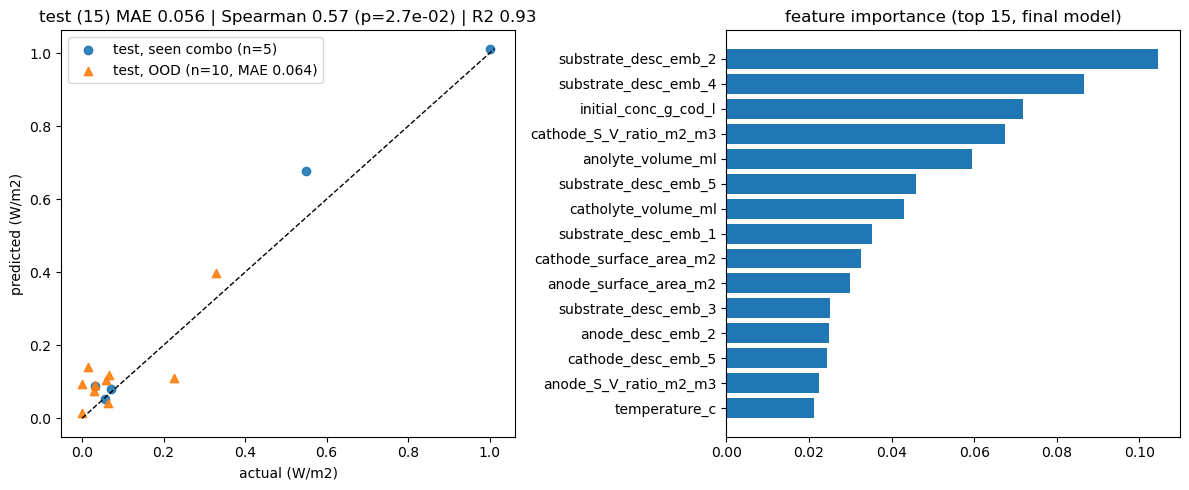

In [15]:
# DIAGNOSTIC PLOTS: test-set parity (step 3) + feature importance
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
seen = ~ood_mask
ax[0].scatter(y_test[seen], test_pred[seen], alpha=0.9, label=f"test, seen combo (n={int(seen.sum())})")
ax[0].scatter(y_test[ood_mask], test_pred[ood_mask], alpha=0.9, marker="^",
              label=f"test, OOD (n={int(ood_mask.sum())}, MAE {ood_metrics['mae']:.3f})")
lo = float(min(y_test.min(), test_pred.min())); hi = float(max(y_test.max(), test_pred.max()))
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("actual (W/m2)"); ax[0].set_ylabel("predicted (W/m2)")
ax[0].set_title("test ({}) MAE {:.3f} | Spearman {:.2f} (p={:.1e}) | R2 {:.2f}".format(
    len(y_test), test_metrics["mae"], test_metrics["spearman"],
    test_metrics["pval"], test_metrics["r2"])); ax[0].legend()
top = importance.head(15)[::-1]
ax[1].barh(top["feature"], top["importance"]); ax[1].set_title("feature importance (top 15, final model)")
fig.tight_layout(); fig.savefig(RESULT_DIR / "diagnostic_plots.png", dpi=200, bbox_inches="tight"); plt.show()